In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 69.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✅ Archivo leído con éxito.
 Tokenización exitosa. Primeras palabras después de limpiar:
['respuestas', 'caso', 'big', 'data', 'salud', 'pública', 'minería', 'datos', 'diego', 'robles', 'cada', 'estudiante', 'debe', 'responder', 'cada', 'pregunta', 'agregando', 'nombre', 'apellido', 'inicio']


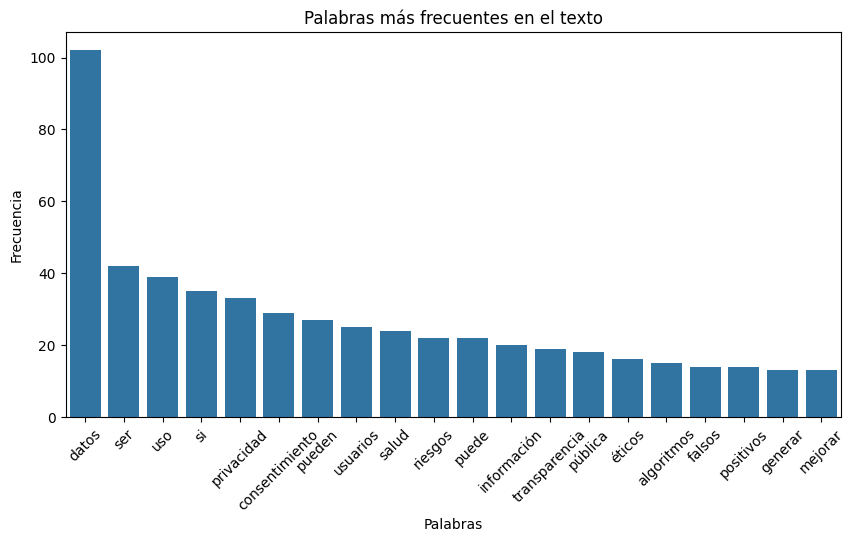

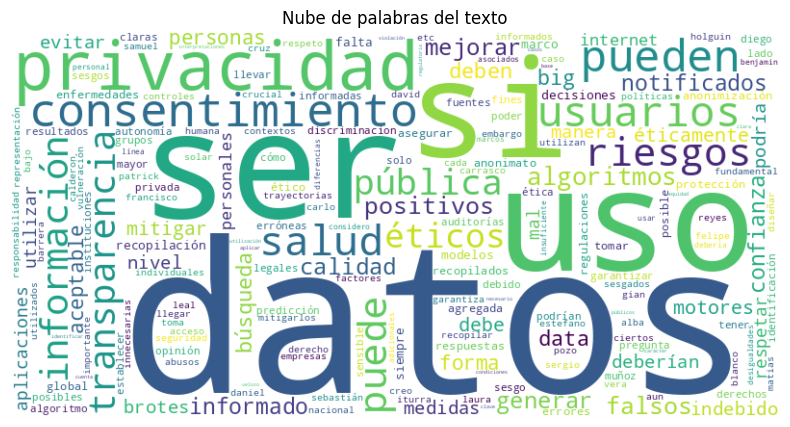


🔹 Bigramas más relevantes después del filtro:
los datos: 34
los usuarios: 25
el uso: 21
la privacidad: 19
salud pública: 17
sus datos: 16
falsos positivos: 14
riesgos éticos: 12
big data: 11
ser notificados: 11
el consentimiento: 11
consentimiento informado: 11
los algoritmos: 10
que se: 10
mejorar la: 10


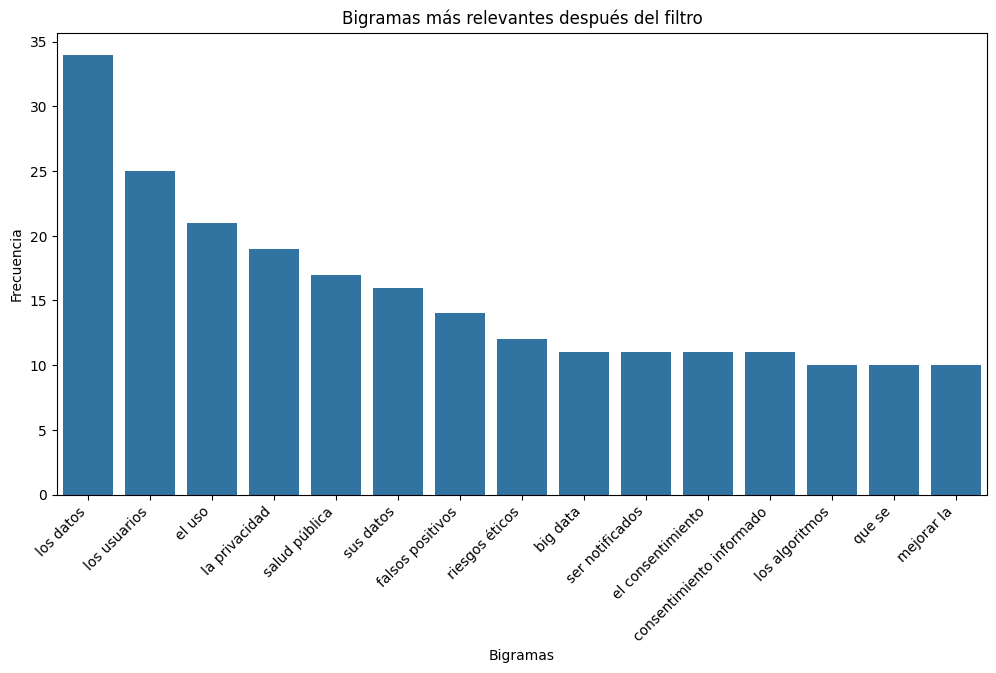

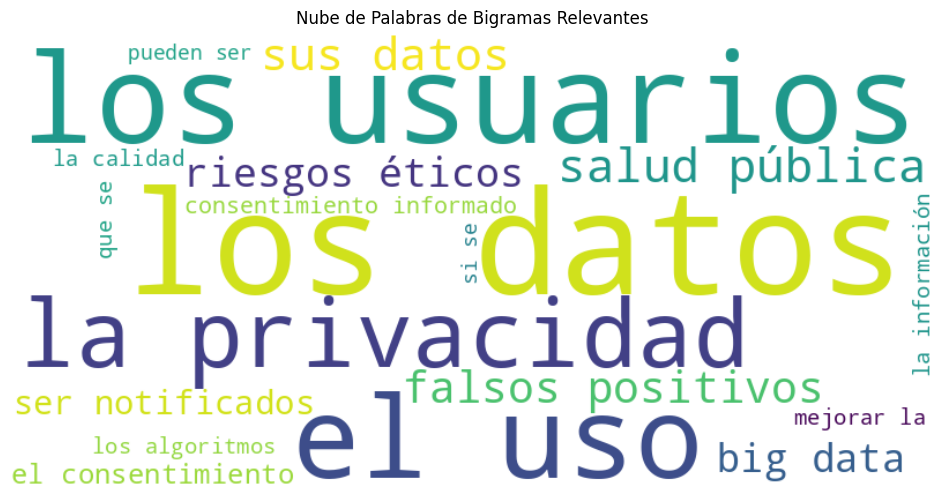

In [ ]:
#  Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Instalar dependencias necesarias (Ejecutar solo si es necesario)
#!pip install --upgrade nltk spacy wordcloud matplotlib seaborn
#!python -m spacy download es_core_news_sm

# Importar librerías
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import string
import os

#  Descargar recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')  # 🔹 Previene errores con word_tokenize

# Cargar el modelo de spaCy para español
nlp = spacy.load("es_core_news_sm")

# Especificar la ruta del archivo en Google Drive
ruta_txt = "/content/drive/MyDrive/Minería de datos UNAB/Clase III/Taller /respuestas.txt"  # Ajusta la ruta si es necesario

#  Leer el archivo de texto
if os.path.exists(ruta_txt):
    with open(ruta_txt, 'r', encoding='utf-8') as file:
        texto = file.read()
    print("✅ Archivo leído con éxito.")
else:
    print(f"⚠️ Error: No se encontró el archivo en {ruta_txt}. Verifica la ruta en Google Drive.")
    texto = None  # Para evitar errores posteriores

# Procesamiento del texto
if texto:
    texto = texto.lower()  # Convertimos a minúsculas
    texto = texto.translate(str.maketrans('', '', string.punctuation))  # Eliminamos puntuación

    #  Lista personalizada de stopwords (eliminamos conectores irrelevantes)
    stopwords_extra = {
        "además", "entonces", "así", "también", "sin embargo", "aunque", "mientras", "luego", "después",
        "porque", "por lo tanto", "pues", "con", "entre", "hacia", "según", "durante", "mediante",
        "incluso", "finalmente", "tal vez", "quizás", "aproximadamente", "casi", "ciertamente",
        "efectivamente", "todavía", "de hecho", "al respecto", "de acuerdo", "por otro lado",
        "ya que", "a pesar de", "en cambio", "en conclusión", "por ejemplo", "de igual manera"
    }

    # Unir las stopwords estándar con nuestra lista personalizada
    stop_words = set(stopwords.words('spanish')).union(stopwords_extra)

    # Tokenización y eliminación de stopwords
    tokens = word_tokenize(texto)  # Tokenización
    tokens_limpios = [word for word in tokens if word.lower() not in stop_words and word.isalpha()]

    print(" Tokenización exitosa. Primeras palabras después de limpiar:")
    print(tokens_limpios[:20])  # Muestra las primeras 20 palabras filtradas

    # Contar palabras más frecuentes
    frecuencia = Counter(tokens_limpios)
    palabras_comunes = frecuencia.most_common(20)

    #  Gráfica de frecuencia de palabras
    plt.figure(figsize=(10,5))
    sns.barplot(x=[p[0] for p in palabras_comunes], y=[p[1] for p in palabras_comunes])
    plt.xticks(rotation=45)
    plt.title("Palabras más frecuentes en el texto")
    plt.xlabel("Palabras")
    plt.ylabel("Frecuencia")
    plt.show()

    # Nube de palabras
    if frecuencia:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(frecuencia)
        plt.figure(figsize=(10,5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title("Nube de palabras del texto")
        plt.show()
    else:
        print("⚠️ No hay suficientes palabras para generar la nube de palabras.")

    #  Generar bigramas y filtrar irrelevantes
    doc = nlp(texto)
    bigrams = [f"{token.text} {doc[i+1].text}" for i, token in enumerate(doc[:-1])]
    bigram_freq = Counter(bigrams).most_common(30)  # Top 30 bigramas antes del filtro

    # Filtrar bigramas irrelevantes
    stopwords_bigramas = {
        "de", "del", "en", "por", "para", "y", "o", "a", "según", "como", "más", "menos"
    }

    def filtrar_bigramas(bigramas):
        return [(bigram, freq) for bigram, freq in bigramas if not any(word in stopwords_bigramas for word in bigram.split())]

    bigramas_filtrados = filtrar_bigramas(bigram_freq)

    #  Mostrar los primeros bigramas filtrados
    print("\n🔹 Bigramas más relevantes después del filtro:")
    for bigram, freq in bigramas_filtrados[:15]:  # Muestra los primeros 15 bigramas relevantes
        print(f"{bigram}: {freq}")

    # Graficar la frecuencia de bigramas después del filtro
    bigramas_filtrados_top = bigramas_filtrados[:15]  # Tomamos los 15 bigramas más frecuentes después del filtro

    if bigramas_filtrados_top:
        plt.figure(figsize=(12, 6))
        sns.barplot(x=[b[0] for b in bigramas_filtrados_top], y=[b[1] for b in bigramas_filtrados_top])
        plt.xticks(rotation=45, ha="right")
        plt.title("Bigramas más relevantes después del filtro")
        plt.xlabel("Bigramas")
        plt.ylabel("Frecuencia")
        plt.show()
    else:
        print("⚠️ No hay suficientes bigramas relevantes para graficar.")

    #  Generar una nube de palabras con los bigramas filtrados
    if bigramas_filtrados:
        bigram_frequencies = {b[0]: b[1] for b in bigramas_filtrados}
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(bigram_frequencies)

        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title("Nube de Palabras de Bigramas Relevantes")
        plt.show()
    else:
        print("⚠️ No hay suficientes bigramas relevantes para la nube de palabras.")

else:
    print("⚠️ No se puede procesar el texto porque la variable está vacía o no existe.")


